# Imports, datapaths 

In [79]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import SimpleITK as sitk
import numpy as np
import monai.transforms as mtf
import torch
from tqdm import tqdm

CT_RATE_PATH = '/mnt/storage/prateek/ct-rate/'

# Output path for preprocess files - I don't have access to Prateeks directory 
TMP_PATH = '/mnt/storage/nickmcarthy/ct-rate/'


# Read dataset csv and (available) image filepaths 

In [108]:
csv_file_name = os.path.join(CT_RATE_PATH, 'train_reports.csv')
root_img_dir = os.path.join(CT_RATE_PATH, 'data_volumes/dataset/train')

df_full = pd.read_csv(csv_file_name)

# Get list of available images 
image_filepaths = set()

for dirpath, _, filenames in os.walk(root_img_dir):
    for file in filenames:
        if file.endswith('.gz'):
            full_path = os.path.join(dirpath, file)
            image_filepaths.add(full_path)

# Filter to available images (we don't have all of the images 
image_filenames = {os.path.basename(x) for x in image_filepaths}

image_fname2path = {os.path.basename(x): x for x in image_filepaths} 

df_full['VolumePath'] = df_full['VolumeName'].map(image_fname2path)

df = df_full[df_full['VolumeName'].isin(image_filenames)]

df.reset_index(inplace=True, drop=True)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3773 entries, 0 to 3772
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   VolumeName              3773 non-null   object
 1   ClinicalInformation_EN  3771 non-null   object
 2   Technique_EN            3773 non-null   object
 3   Findings_EN             3773 non-null   object
 4   Impressions_EN          3771 non-null   object
 5   VolumePath              3773 non-null   object
dtypes: object(6)
memory usage: 177.0+ KB


In [110]:
df.head(5)

,VolumeName,ClinicalInformation_EN,Technique_EN,Findings_EN,Impressions_EN,VolumePath
0,train_1_a_1.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,/mnt/storage/prateek/ct-rate/data_volumes/data...
1,train_1_a_2.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,/mnt/storage/prateek/ct-rate/data_volumes/data...
2,train_2_a_1.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,/mnt/storage/prateek/ct-rate/data_volumes/data...
3,train_2_a_2.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,/mnt/storage/prateek/ct-rate/data_volumes/data...
4,train_3_a_1.nii.gz,Kidney transplant candidate.,Non-contrast images were taken in the axial pl...,Right thyroid lobe sizes increased. Evaluation...,Calcific atheromatous plaques in coronary art...,/mnt/storage/prateek/ct-rate/data_volumes/data...


In [111]:
# Largest text input - note 
max_text = df.loc[df['Findings_EN'].astype(str).map(lambda x: len(x.split())).idxmax(), 'Findings_EN']
word_count = len(str(max_text).split())
print(word_count)

# Note - the word count on the unfiltered dataset was 1035 

732


# Train-test split 

In [123]:
train_idx, test_idx = train_test_split(df.index, test_size=0.1, random_state=1916)

train_df = df.loc[train_idx]
test_df = df.loc[test_idx]

df['train'] = True
df.loc[test_idx, 'train'] = False 

print(f"Train size: {len(train_idx)}\nTest size: {len(test_idx)}")

Train size: 3396
Test size: 378


# Preprocessing 

In [127]:

# Resize nifti images to this size 
output_img_size = (128, 256, 256)  # (C, H, W)

# The new image dir 
new_root_img_dir = os.path.join(TMP_PATH, 'data_volumes/dataset/train_256')
os.makedirs(new_root_img_dir, exist_ok=True)


In [128]:
# Transform Function 
def transform_3d_img(nifty_img_name, img_size):
    """
    Transforms a 3D NIfTI image to a normalized tensor of shape (C, H, W)
    """
    image = sitk.ReadImage(nifty_img_name)
    image_array = sitk.GetArrayFromImage(image).astype(np.float32)  # (D, H, W)

    image_array = np.expand_dims(image_array, axis=0)  # (1, D, H, W)
    image_tensor = torch.from_numpy(image_array).contiguous().float()

    transform = mtf.Compose([
        mtf.CropForeground(allow_smaller=True),
        mtf.Resize(spatial_size=img_size, mode="bilinear")
    ])

    img_trans = transform(image_tensor).squeeze(0)
    img_trans_np = img_trans.numpy()
    img_trans_np -= img_trans_np.min()
    img_trans_np /= np.clip(img_trans_np.max(), a_min=1e-8, a_max=None)

    return img_trans_np


In [ ]:
# Process and Save Images with Progress Bar

for idx, filepath in tqdm(enumerate(df['VolumePath']), desc="Processing images", total=len(df)):
    # Transform and write preprocessed image to new location 
    rel_path = os.path.relpath(os.path.dirname(filepath), root_img_dir)
    new_dirpath = os.path.join(new_root_img_dir, rel_path)
    
    os.makedirs(new_dirpath, exist_ok=True)  # Create new output directory
    
    output_path = os.path.join(new_dirpath, os.path.basename(filepath))  
    
    out_img = transform_3d_img(filepath, output_img_size)
    
    sitk.WriteImage(sitk.GetImageFromArray(out_img), output_path, True)

    # Update df['VolumePath'] with new output_path
    df.at[idx, 'VolumePath'] = output_path

# Write the processed train_reports to disk 
df_newpath = os.path.join(new_root_img_dir, 'train_reports_256.csv')
df.to_csv(df_newpath, index=False)


Processing images:   1%|██                                                                                                                                                   | 52/3774 [03:51<6:00:02,  5.80s/it]

# Test a transformed image 

In [ ]:
test_filepath = df.iloc[111, 'VolumePath'] 

test_img = sitk.ReadImage(test_filepath)
size_test = test_img.GetSize()
print("Image size (Width, Height, Depth):", size_test)

In [109]:
img_trans_np.max()

1.0

In [11]:
test_img = sitk.ReadImage(df.iloc[5]['VolumePath'])
size_test = test_img.GetSize()
print("Image size (Width, Height, Depth):", size_test)

Image size (Width, Height, Depth): (256, 256, 128)


In [131]:
output_img_size['channel']

128

Image shape (D, H, W): (239, 1024, 1024)


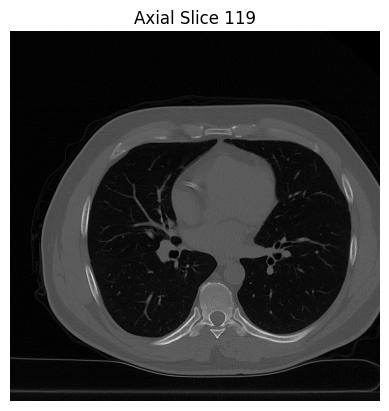

In [3]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

# 1. Read a 3D image (e.g., .nii, .mhd, .nrrd)
image_path = "/mnt/recsys/prateek/ct-rate/data_volumes/dataset/train/train_532/train_532_a/train_532_a_2.nii.gz"  # or .mhd, .nrrd, etc.
image = sitk.ReadImage(image_path)

# 2. Convert to NumPy array
image_array = sitk.GetArrayFromImage(image)  # shape: (D, H, W)

print("Image shape (D, H, W):", image_array.shape)

middle_slice = image_array.shape[0] // 2
slice_image = image_array[middle_slice]

# Display the slice
plt.imshow(slice_image, cmap='gray')
plt.title(f"Axial Slice {middle_slice}")
plt.axis('off')
plt.show()

Image shape (D, H, W): (128, 256, 256)


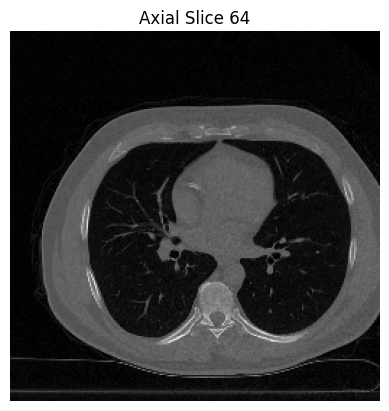

In [4]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

# 1. Read a 3D image (e.g., .nii, .mhd, .nrrd)
image_path = "/mnt/recsys/prateek/ct-rate/data_volumes/dataset/train_256/train_532/train_532_a/train_532_a_2.nii.gz"  # or .mhd, .nrrd, etc.
image = sitk.ReadImage(image_path)

# 2. Convert to NumPy array
image_array = sitk.GetArrayFromImage(image)  # shape: (D, H, W)

print("Image shape (D, H, W):", image_array.shape)

middle_slice = image_array.shape[0] // 2
slice_image = image_array[middle_slice]

# Display the slice
plt.imshow(slice_image, cmap='gray')
plt.title(f"Axial Slice {middle_slice}")
plt.axis('off')
plt.show()

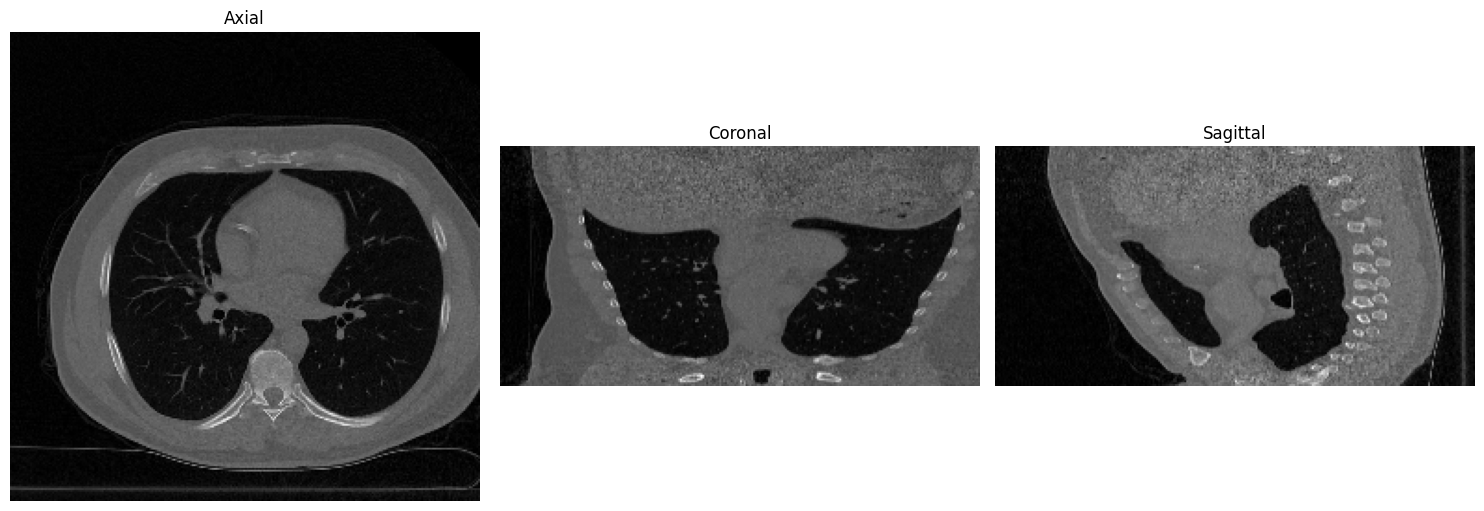

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axs[0].imshow(image_array[image_array.shape[0] // 2], cmap='gray')
axs[0].set_title("Axial")

# Coronal
axs[1].imshow(image_array[:, image_array.shape[1] // 2, :], cmap='gray')
axs[1].set_title("Coronal")

# Sagittal
axs[2].imshow(image_array[:, :, image_array.shape[2] // 2], cmap='gray')
axs[2].set_title("Sagittal")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()